In [1]:
import os
import xesmf  as xe
import xarray as xr
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
from cartopy import config
import cartopy.crs as ccrs
import pygmt
import psutil
memory_info = psutil.virtual_memory()
print(f"Available memory: {memory_info.available} bytes")
print(f"Available memory: {memory_info.available / (1024 ** 2)} MB")
print(f"Available memory: {memory_info.available / (1024 ** 3)} GB")

Available memory: 959350099968 bytes
Available memory: 914907.55078125 MB
Available memory: 893.4644050598145 GB


In [2]:
D_save     = "/g/data/jk72/da1339/GRAPHICAL/IC/"
G_CICE_0p1 = xr.open_dataset("/scratch/jk72/da1339/cice-dirs/input/AFIM/grid/0p1/linked_files/grid.nc")
iced       = xr.open_dataset("/g/data/jk72/da1339/afim_input/initial_conditions/AOM2_0p1_1997/iced.1997-10-01-00000.nc",decode_times=False)
TLON       = G_CICE_0p1.tlon.values*180/np.pi
TLAT       = G_CICE_0p1.tlat.values*180/np.pi
ULON       = G_CICE_0p1.ulon.values*180/np.pi
ULAT       = G_CICE_0p1.ulat.values*180/np.pi
iced

0.3.0


<xarray.Dataset>
Dimensions:       (nj: 2700, ni: 3600, ncat: 5)
Dimensions without coordinates: nj, ni, ncat
Data variables: (12/35)
    uvel          (nj, ni) float64 ...
    vvel          (nj, ni) float64 ...
    scale_factor  (nj, ni) float64 ...
    swvdr         (nj, ni) float64 ...
    swvdf         (nj, ni) float64 ...
    swidr         (nj, ni) float64 ...
    ...            ...
    qice002       (ncat, nj, ni) float64 ...
    sice003       (ncat, nj, ni) float64 ...
    qice003       (ncat, nj, ni) float64 ...
    sice004       (ncat, nj, ni) float64 ...
    qice004       (ncat, nj, ni) float64 ...
    qsno001       (ncat, nj, ni) float64 ...
Attributes:
    istep1:     2243920
    time:       1254355200.0
    time_forc:  0.0
    nyr:        40
    month:      10
    mday:       1
    sec:        0

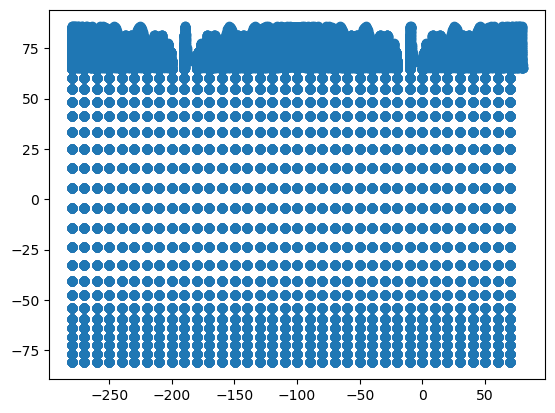

In [10]:
plt.scatter( TLON[:,0:-1:100], TLAT[0:-1:100,:] )

<xarray.DataArray (y: 2700, x: 3600)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
    lon      (y, x) float64 279.9 279.8 279.7 279.6 ... 80.0 80.0 80.0 80.0
    lat      (y, x) float64 -81.09 -81.09 -81.09 -81.09 ... 65.08 65.04 64.99
Dimensions without coordinates: y, x
min: <xarray.DataArray ()>
array(0.)
max: <xarray.DataArray ()>
array(1.59320265)


makecpt [WARNING]: cmocean/speed is a discrete CPT. You can stretch it (-T<min>/<max>) but not interpolate it (-T<min>/<max>/<inc>).
makecpt [WARNING]: Selecting the given range and ignoring the increment setting.
grdimage [WARNING]: Your grid y's or latitudes appear to be outside the map region and will be skipped.
grdimage [WARNING]: No grid or image inside plot domain


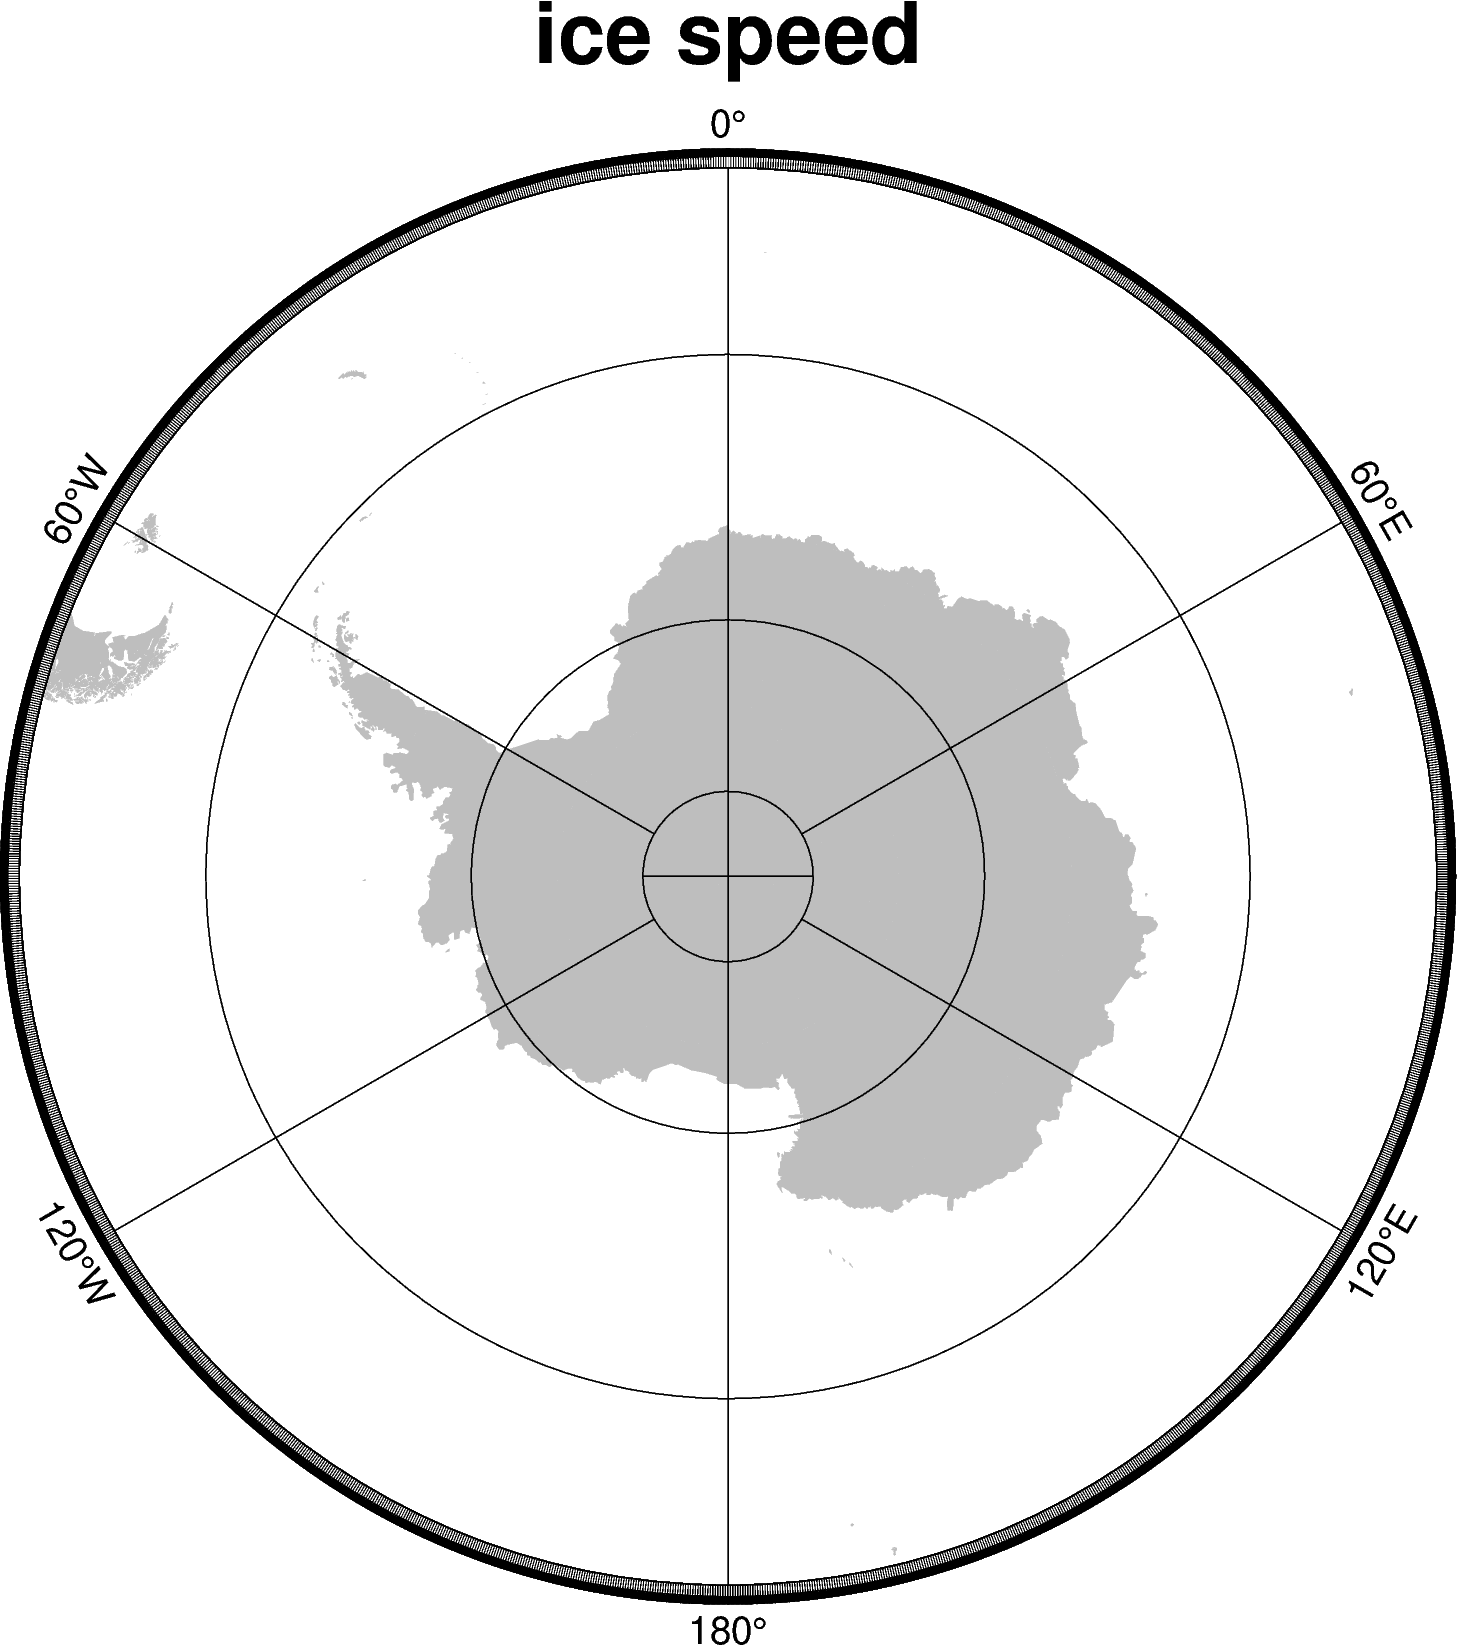

In [3]:
spd        = np.sqrt( iced.uvel.values**2 + iced.vvel.values**2 )
spd[spd>5] = np.nan
P_save     = os.path.join(D_save,"0p1","19971001_ice_speed.png")
da         = xr.DataArray(data=spd, dims=["y", "x"], coords=dict(lon=(["y","x"], np.abs(ULON)), lat=(["y","x"], ULAT)))
print(da)
print(f"min: {da.min()}")
print(f"max: {da.max()}")
fig = pygmt.Figure()
pygmt.makecpt(cmap="cmocean/speed", series=[0, 3, .1])
fig.coast(region=[0,360,-90,-50], projection="S0/-90/12c", frame="ag", land="gray")
fig.grdimage( grid=da, projection="S0/-90/12c", frame=["WSrt+tice speed", "xa0.1", "ya0.1"], cmap=True )
fig.show()

In [3]:
G_BRAN = xr.open_dataset("/g/data/jk72/da1339/grids/BRAN_ocean_grid.nc")
G_BRAN_SPEC = xr.open_dataset("/g/data/jk72/da1339/grids/BRAN/grid_spec.nc")
G_BRAN = G_BRAN.isel(st_ocean=0).drop_vars('st_ocean')
G_BRAN = G_BRAN.rename_dims({'xt_ocean':'xt','yt_ocean':'yt','xu_ocean':'xu','yu_ocean':'yu'})
Gt_BRAN = xr.Dataset()
Gt_BRAN['lon'] = (('yt','xt'), G_BRAN_SPEC.x_T.values)
Gt_BRAN['lat'] = (('yt','xt'), G_BRAN_SPEC.y_T.values)
#LON_B,LAT_B     = np.meshgrid( G_BRAN_SPEC.xba.values , G_BRAN_SPEC.yba.values )
#Gt_BRAN['lon_b'] = (('yb','xb'), LON_B)
#Gt_BRAN['lat_b'] = (('yb','xb'), LAT_B)
Gt_BRAN['mask'] = (('yt','xt'), G_BRAN.tmask.values)
Gt_BRAN

0.3.0


<xarray.Dataset>
Dimensions:  (yt: 1500, xt: 3600)
Dimensions without coordinates: yt, xt
Data variables:
    lon      (yt, xt) float64 0.05 0.15 0.25 0.35 ... 359.7 359.8 359.9 360.0
    lat      (yt, xt) float64 -74.95 -74.95 -74.95 -74.95 ... 74.95 74.95 74.95
    mask     (yt, xt) float32 nan nan nan nan nan nan ... 1.0 1.0 1.0 1.0 1.0

In [4]:
G_CICE5         = xr.open_dataset("/g/data/jk72/da1339/grids/CICE5_0p25_grid.nc")
G_CICE5_mask    = xr.open_dataset("/scratch/jk72/da1339/cice-dirs/input/AFIM/grid/0p25/linked_files/kmt.nc")
lon_centers     = G_CICE5.tlon.values*180/np.pi
lat_centers     = G_CICE5.tlat.values*180/np.pi
Gt_CICE         = xr.Dataset()
Gt_CICE['lon']  = (('yt','xt'), lon_centers)
Gt_CICE['lat']  = (('yt','xt'), lat_centers)
Gt_CICE['mask'] = (('yt','xt'), G_CICE5_mask.kmt.values)
Gt_CICE

<xarray.Dataset>
Dimensions:  (yt: 1080, xt: 1440)
Dimensions without coordinates: yt, xt
Data variables:
    lon      (yt, xt) float64 -279.9 -279.6 -279.4 -279.1 ... 80.0 80.0 80.0
    lat      (yt, xt) float64 -81.08 -81.08 -81.08 -81.08 ... 65.24 65.13 65.03
    mask     (yt, xt) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0

In [36]:
Gt_BRAN.to_netcdf("/g/data/jk72/da1339/grids/BRAN_t_grid.20240401.nc",mode='w')
Gt_CICE.to_netcdf("/g/data/jk72/da1339/grids/CICE5_t_grid.20240401.nc",mode='w')

In [5]:
reG = xe.Regridder( Gt_BRAN, Gt_CICE, method="patch", extrap_method="nearest_s2d", periodic=False, reuse_weights=True, filename="/g/data/jk72/da1339/grids/weights/map_BRAN_to_CICE5_0p25_t_grid_patch_extrap_neareststod.20240401.nc")

In [11]:
BRAN_temp = xr.open_dataset("/g/data/gb6/BRAN/BRAN2020/daily/ocean_temp_1993_01.nc")
BRAN_sst  = BRAN_temp.isel(st_ocean=0).drop_vars('st_ocean')
SST_reG   = reG(BRAN_sst.temp)

/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/xesmf/frontend.py:696: UserWarning: Using dimensions ('yt_ocean', 'xt_ocean') from data variable temp as the horizontal dimensions for the regridding.
  warnings.warn(


KeyboardInterrupt: 

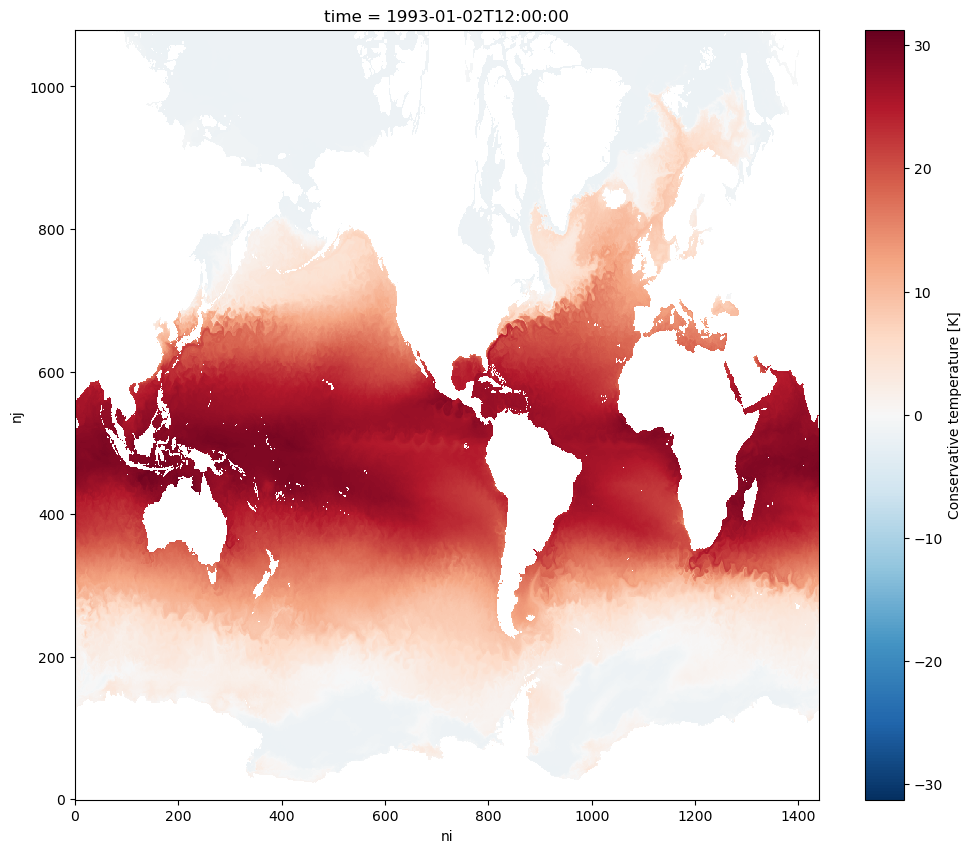

In [6]:
AOM2_daily = xr.open_dataset("/scratch/jk72/da1339/afim_input/AOM2/0p25/daily/AOM2_1993.nc")
AOM2_daily.isel(time=1).sst.plot(figsize=(12,10))

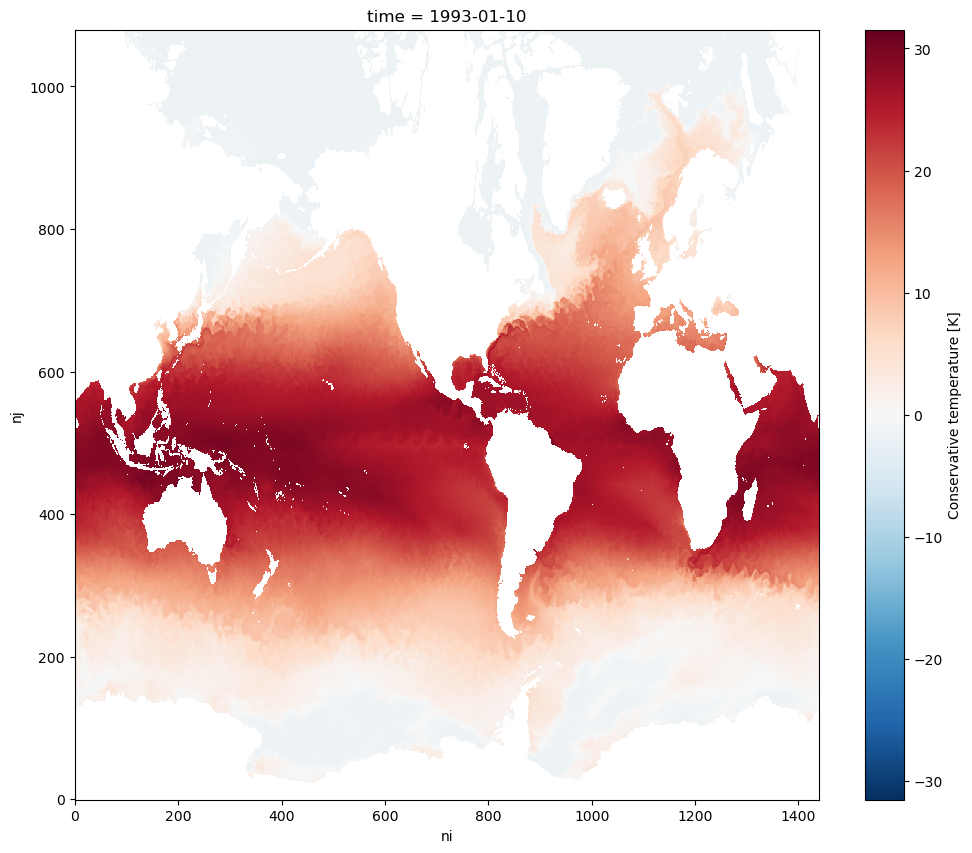

In [7]:
AOM2_weekly = xr.open_dataset("/scratch/jk72/da1339/afim_input/AOM2/0p25/weekly/AOM2_1993.nc")
AOM2_weekly.isel(time=1).sst.plot(figsize=(12,10))

In [8]:
AOM2_daily

<xarray.Dataset>
Dimensions:   (time: 365, nj: 1080, ni: 1440)
Coordinates:
  * time      (time) datetime64[ns] 1993-01-01T12:00:00 ... 1993-12-31T12:00:00
    xt_ocean  (nj, ni) float64 ...
    xu_ocean  (nj, ni) float64 ...
    yt_ocean  (nj, ni) float64 ...
    yu_ocean  (nj, ni) float64 ...
Dimensions without coordinates: nj, ni
Data variables:
    sss       (time, nj, ni) float32 ...
    sst       (time, nj, ni) float32 ...
    u         (time, nj, ni) float32 ...
    v         (time, nj, ni) float32 ...
Attributes:
    NCO:      netCDF Operators version 5.0.5 (Homepage = http://nco.sf.net, C...
    history:  Wed Mar 20 08:53:46 2024: ncatted -O -a _FillValue,,o,f,-1e20 /...

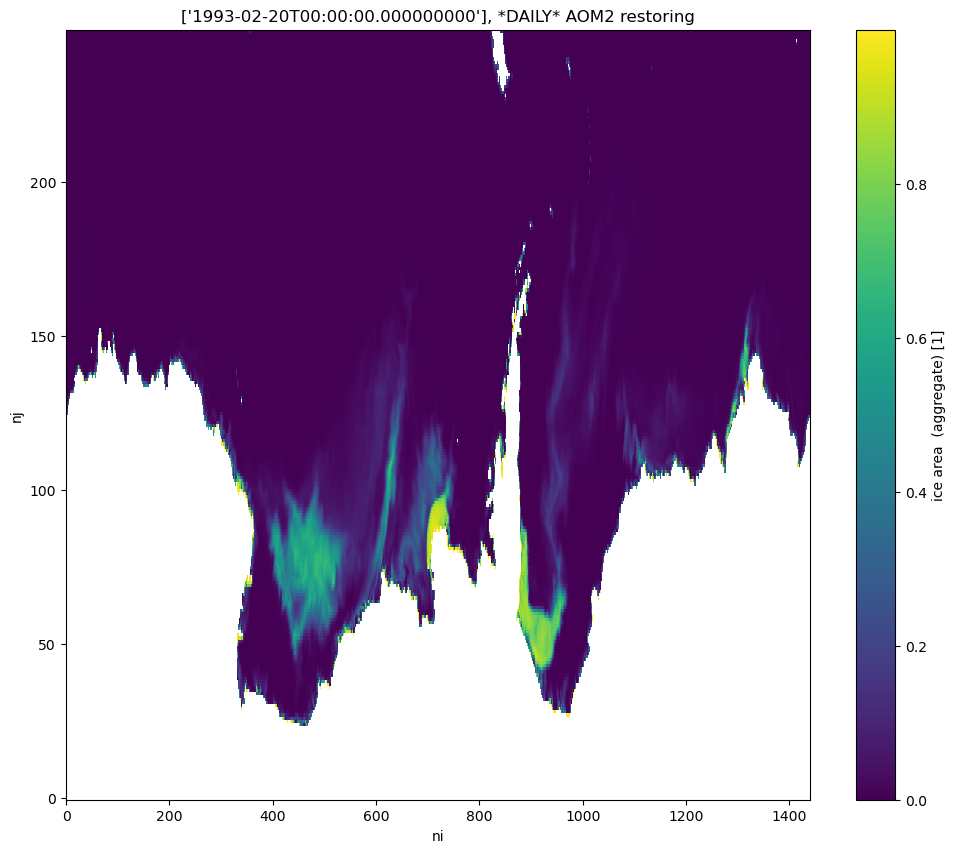

In [63]:
CICE_daily = xr.open_dataset("/scratch/jk72/da1339/cice-dirs/runs/afim_era5/history/iceh.1993-02-19.nc")
CICE_daily.aice.isel(nj=slice(0,250)).plot(figsize=(12,10))
plt.title(f"{CICE_daily.time.values}, *DAILY* AOM2 restoring")
plt.savefig("/g/data/jk72/da1339/GRAPHICAL/quick_snapshot_aice_ant_daily_ocn_frcg.png")

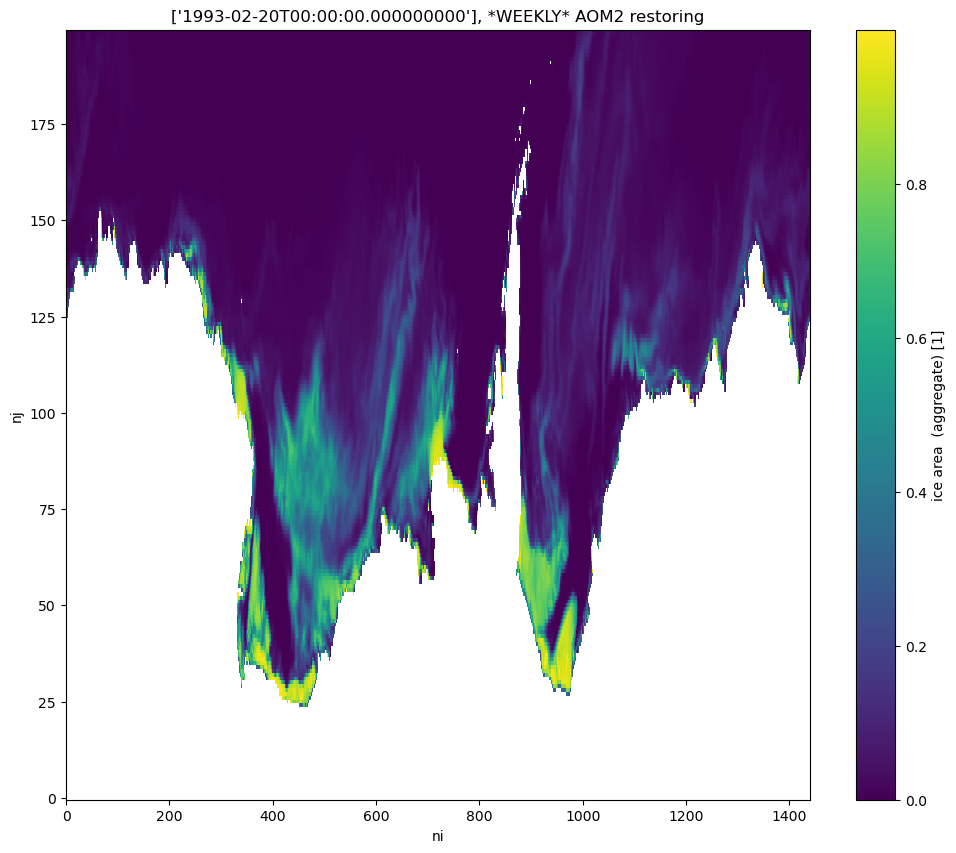

In [64]:
CICE_weekly = xr.open_dataset("/scratch/jk72/da1339/cice-dirs/runs/afim_era5_1/history/iceh.1993-02-19.nc")
CICE_weekly.aice.isel(nj=slice(0,200)).plot(figsize=(12,10))
plt.title(f"{CICE_weekly.time.values}, *WEEKLY* AOM2 restoring")
plt.savefig("/g/data/jk72/da1339/GRAPHICAL/quick_snapshot_aice_ant_weekly_ocn_frcg.png")

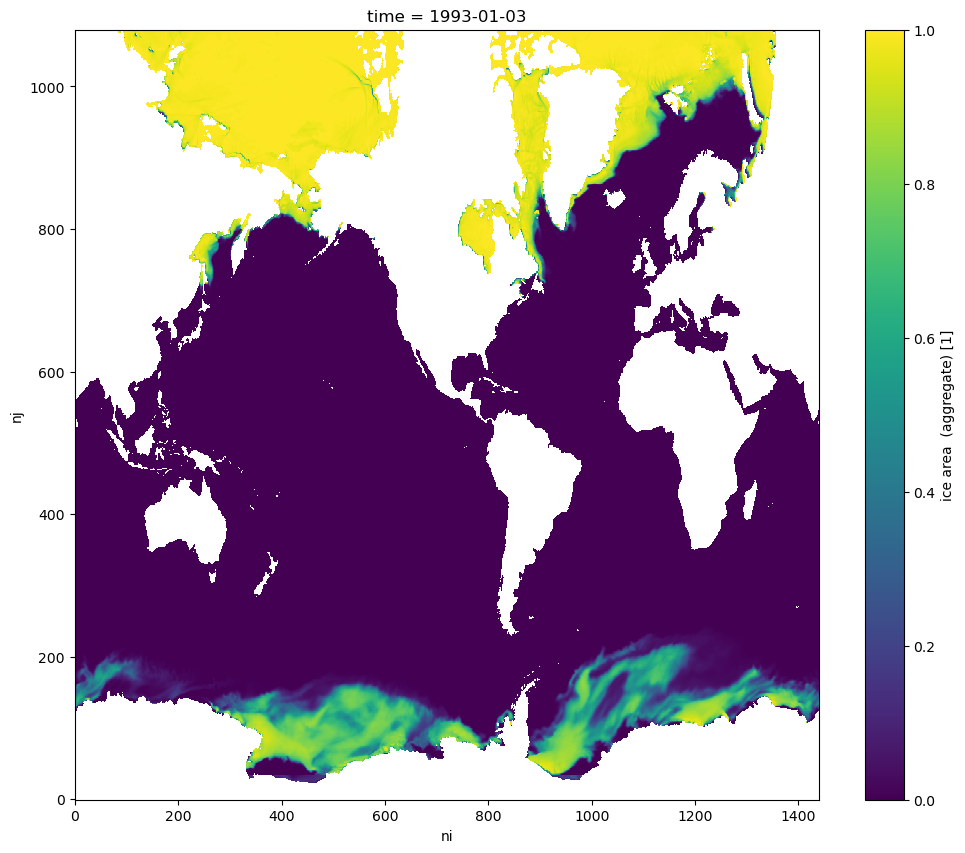

In [37]:
CICE_monthly = xr.open_dataset("/scratch/jk72/da1339/cice-dirs/runs/afim_era5_2/history/iceh.1993-01-07.nc")
CICE_monthly.aice.isel(nj=slice(0,200plot(figsize=(12,10))

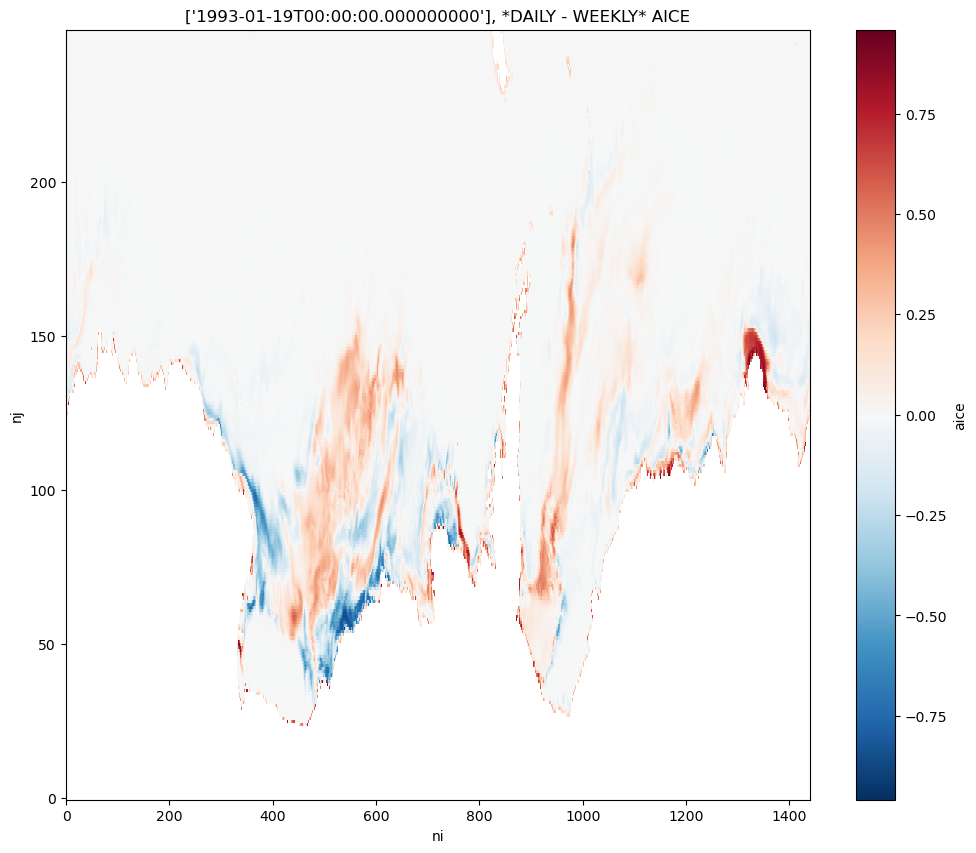

In [61]:
CICE_diff = CICE_daily.aice - CICE_weekly.aice
CICE_diff.isel(nj=slice(0,250)).plot(figsize=(12,10))
plt.title(f"{CICE_daily.time.values}, *DAILY - WEEKLY* AICE")
plt.savefig("/g/data/jk72/da1339/GRAPHICAL/quick_snapshot_aice_ant_daily_minus_weekly_difference.png")

In [ ]:
fig = pygmt.Figure()
fig.coast(region=[66,73,-69,-67],
          projection="M20c",#"G70/-70/10i"
          land="grey",
          shorelines=True,
          frame="ag",)
fig.basemap(rose="jTR+w1.5c+lO,E,S,N+o-0.1c/3c",map_scale="jBL+w50k+o0.5c/0.5c+f",frame="+tACCESS-OM2 1/10 & 1/4-degree")
fig.plot(x=G_CICE5_0p25.tlon.values.flatten()[0:-1:1]*180/np.pi, y=G_CICE5_0p25.tlat.values.flatten()[0:-1:1]*180/np.pi, 
         style="c0.1c", fill="blue")#, pen="black")
fig.plot(x=G_CICE5_0p1.tlon.values.flatten()[0:-1:1]*180/np.pi, y=G_CICE5_0p1.tlat.values.flatten()[0:-1:1]*180/np.pi, 
         style="c0.05c", fill="red")#, pen="black")
fig.savefig("/g/data/jk72/da1339/GRAPHICAL/AOM2_grids_0p1_0p25_CapeDarnley.png")
fig.show()

In [6]:
def calculate_corners(center_lat, center_lon):
    """Calculate corner coordinates by averaging neighbor cells
    """

    # get rank
    rank = len(center_lat.dims)

    if rank == 1:
        # get dimensions
        nlon = center_lon.size
        nlat = center_lat.size

        # convert center points from 1d to 2d
        center_lat2d = da.broadcast_to(center_lat.values[None,:], (nlon, nlat))
        center_lon2d = da.broadcast_to(center_lon.values[:,None], (nlon, nlat))
    elif rank == 2:
        # get dimensions
        dims = center_lon.shape
        nlon = dims[0]
        nlat = dims[1] 

        # just rename and convert to dask array
        center_lat2d = da.from_array(center_lat)
        center_lon2d = da.from_array(center_lon)
    else:
        print('Unrecognized grid! The rank of coordinate variables can be 1 or 2 but it is {}.'.format(rank))
        sys.exit(2)

    # calculate corner coordinates for latitude, counterclockwise order, imposing Fortran ordering
    center_lat2d_ext = da.from_array(np.pad(center_lat2d.compute(), (1,1),  mode='reflect', reflect_type='odd'))

    ur = (center_lat2d_ext[1:-1,1:-1]+
          center_lat2d_ext[0:-2,1:-1]+
          center_lat2d_ext[1:-1,2:]+
          center_lat2d_ext[0:-2,2:])/4.0
    ul = (center_lat2d_ext[1:-1,1:-1]+
          center_lat2d_ext[0:-2,1:-1]+
          center_lat2d_ext[1:-1,0:-2]+
          center_lat2d_ext[0:-2,0:-2])/4.0
    ll = (center_lat2d_ext[1:-1,1:-1]+
          center_lat2d_ext[1:-1,0:-2]+
          center_lat2d_ext[2:,1:-1]+
          center_lat2d_ext[2:,0:-2])/4.0
    lr = (center_lat2d_ext[1:-1,1:-1]+
          center_lat2d_ext[1:-1,2:]+
          center_lat2d_ext[2:,1:-1]+
          center_lat2d_ext[2:,2:])/4.0

    # this looks clockwise ordering but it is transposed and becomes counterclockwise, bit-to-bit with NCL 
    corner_lat = da.stack([ul.T.reshape((-1,)).T, ll.T.reshape((-1,)).T, lr.T.reshape((-1,)).T, ur.T.reshape((-1,)).T], axis=1)

    # calculate corner coordinates for longitude, counterclockwise order, imposing Fortran ordering
    center_lon2d_ext = da.from_array(np.pad(center_lon2d.compute(), (1,1),  mode='reflect', reflect_type='odd'))

    ur = (center_lon2d_ext[1:-1,1:-1]+
          center_lon2d_ext[0:-2,1:-1]+
          center_lon2d_ext[1:-1,2:]+
          center_lon2d_ext[0:-2,2:])/4.0
    ul = (center_lon2d_ext[1:-1,1:-1]+
          center_lon2d_ext[0:-2,1:-1]+
          center_lon2d_ext[1:-1,0:-2]+
          center_lon2d_ext[0:-2,0:-2])/4.0
    ll = (center_lon2d_ext[1:-1,1:-1]+
          center_lon2d_ext[1:-1,0:-2]+
          center_lon2d_ext[2:,1:-1]+
          center_lon2d_ext[2:,0:-2])/4.0
    lr = (center_lon2d_ext[1:-1,1:-1]+
          center_lon2d_ext[1:-1,2:]+
          center_lon2d_ext[2:,1:-1]+
          center_lon2d_ext[2:,2:])/4.0

    # this looks clockwise ordering but it is transposed and becomes counterclockwise, bit-to-bit with NCL 
    corner_lon = da.stack([ul.T.reshape((-1,)).T, ll.T.reshape((-1,)).T, lr.T.reshape((-1,)).T, ur.T.reshape((-1,)).T], axis=1)

    return center_lat2d, center_lon2d, corner_lat, corner_lon 

In [7]:
def write_to_esmf_mesh(filename, center_lat, center_lon, corner_lat, corner_lon, mask, area=None):
    """
    Writes ESMF Mesh to file
    dask array doesn't support order='F' for Fortran-contiguous (row-major) order
    the workaround is to arr.T.reshape.T
    """
    # create array with unique coordinate pairs
    # remove coordinates that are shared between the elements
    corner_pair = da.stack([corner_lon.T.reshape((-1,)).T, corner_lat.T.reshape((-1,)).T], axis=1)

    # REPLACED: corner_pair_uniq = dd.from_dask_array(corner_pair).drop_duplicates().to_dask_array(lengths=True)
    # following reduces memory by %17
    corner_pair_uniq = dd.from_dask_array(corner_pair).drop_duplicates().values
    corner_pair_uniq.compute_chunk_sizes()

    # check size of unique coordinate pairs
    dims = mask.shape
    nlon = dims[0]
    nlat = dims[1]
    elem_conn_size = nlon*nlat+nlon+nlat+1
    if corner_pair_uniq.shape[0] != elem_conn_size:
        print('The size of unique coordinate pairs is {} but expected size is {}!'.format(corner_pair_uniq.shape[0], elem_conn_size))
        print('Please check the input file or try to force double precision with --double option. Exiting ...')
        sys.exit(2)

    # create element connections
    corners = dd.concat([dd.from_dask_array(c) for c in [corner_lon.T.reshape((-1,)).T, corner_lat.T.reshape((-1,)).T]], axis=1)   
    corners.columns = ['lon', 'lat']
    elem_conn = corners.compute().groupby(['lon','lat'], sort=False).ngroup()+1
    elem_conn = da.from_array(elem_conn.to_numpy())

    # create new dataset for output
    out = xr.Dataset()

    out['origGridDims'] = xr.DataArray(np.array(center_lon.shape, dtype=np.int32),
                                       dims=('origGridRank'))

    out['nodeCoords'] = xr.DataArray(corner_pair_uniq,
                                     dims=('nodeCount', 'coordDim'),
                                     attrs={'units': 'degrees'})

    out['elementConn'] = xr.DataArray(elem_conn.T.reshape((4,-1)).T,
                                      dims=('elementCount', 'maxNodePElement'),
     		                      attrs={'long_name': 'Node indices that define the element connectivity'})
    out.elementConn.encoding = {'dtype': np.int32}

    out['numElementConn'] = xr.DataArray(4*np.ones(center_lon.size, dtype=np.int32),
                                         dims=('elementCount'),
                                         attrs={'long_name': 'Number of nodes per element'})

    out['centerCoords'] = xr.DataArray(da.stack([center_lon.T.reshape((-1,)).T,
                                                 center_lat.T.reshape((-1,)).T], axis=1),
                                          dims=('elementCount', 'coordDim'),
                                          attrs={'units': 'degrees'})

    # add area if it is available
    if area:
        out['elementArea'] = xr.DataArray(area.T.reshape((-1,)).T,
                                          dims=('elementCount'),
                                          attrs={'units': 'radians^2',
                                                 'long_name': 'area weights'})     

    # add mask
    out['elementMask'] = xr.DataArray(mask.T.reshape((-1,)).T,
                                      dims=('elementCount'),
                                      attrs={'units': 'unitless'})
    out.elementMask.encoding = {'dtype': np.int32}

    # force no '_FillValue' if not specified
    for v in out.variables:
        if '_FillValue' not in out[v].encoding:
            out[v].encoding['_FillValue'] = None

    # add global attributes
    out.attrs = {'title': 'ESMF unstructured grid file for rectangular grid with {} dimension'.format('x'.join(list(map(str,center_lat.shape)))),
                 'created_by': "dpath2o, daniel.atwater@utas.edu.au",
                 'date_created': '{}'.format(datetime.now()),
                 'conventions': 'ESMFMESH',
                }

    # write output file
    if filename is not None:
        print('Writing {} ...'.format(filename))
        out.to_netcdf(filename)

In [27]:
def write_to_scrip(filename, center_lat, center_lon, corner_lat, corner_lon, mask, area=None):
    """
    Writes SCRIP grid definition to file
    dask array doesn't support order='F' for Fortran-contiguous (row-major) order
    the workaround is to arr.T.reshape.T
    """
    # create new dataset for output 
    out = xr.Dataset()
    out['grid_dims']       = xr.DataArray(np.array(center_lat.shape, dtype=np.int32), dims=('grid_rank',)) 
    out.grid_dims.encoding = {'dtype': np.int32}
    out['grid_center_lat'] = xr.DataArray(center_lat.T.reshape((-1,)).T, dims=('grid_size'), attrs={'units': 'degrees'})
    print(xr.DataArray(center_lat.T.reshape((-1,)).T, dims=('grid_size'), attrs={'units': 'degrees'}))
    out['grid_center_lon'] = xr.DataArray(center_lon.T.reshape((-1,)).T, dims=('grid_size'), attrs={'units': 'degrees'})
    out['grid_corner_lat'] = xr.DataArray(corner_lat.T.reshape((4, -1)).T, dims=('grid_size','grid_corners'), attrs={'units': 'degrees'})
    out['grid_corner_lon'] = xr.DataArray(corner_lon.T.reshape((4, -1)).T, dims=('grid_size','grid_corners'), attrs={'units': 'degrees'})
    # include area if it is available
    if area:
        out['grid_area'] = xr.DataArray(area.T.reshape((-1,)).T, dims=('grid_size'), attrs={'units': 'radians^2', 'long_name': 'area weights'})
    out['grid_imask']       = xr.DataArray(mask.T.reshape((-1,)).T, dims=('grid_size'),attrs={'units': 'unitless'})
    out.grid_imask.encoding = {'dtype': np.int32}
    # force no '_FillValue' if not specified
    for v in out.variables:
        if '_FillValue' not in out[v].encoding:
            out[v].encoding['_FillValue'] = None
    # add global attributes
    out.attrs = {'title': 'Rectangular grid with {} dimension'.format('x'.join(list(map(str,center_lat.shape)))),
                 'created_by': "dpath2o, daniel.atwater@utas.edu.au",
                 'date_created': '{}'.format(datetime.now()),
                 'conventions': 'SCRIP'}
    print(out)
    print(out.grid_dims.values)
    print(out.grid_center_lon.values)
    print(out.grid_center_lat.values)
    print(out.grid_corner_lon.values)
    print(out.grid_corner_lat.values)
    print(out.grid_imask.values)
    out = out.compute()
    # write output file
    if filename is not None:
        print('Writing {} ...'.format(filename))
        out.to_netcdf(filename) 

In [30]:
ifile     = '/home/581/da1339/DATA/grids/BRAN_t_grid.20240401.nc'
ofile     = '/home/581/da1339/DATA/grids/BRAN_t_grid.SCRIP.20240402.nc'
oformat   = 'SCRIP'
overwrite = True
flip      = False
latrev    = False
latvar    = 'lat'
lonvar    = 'lon'
maskvar   = 'mask'
maskcal   = True
addarea   = False
double    = False
print("Configuration:")
print("ifile     = {}".format(ifile))
print("ofile     = {}".format(ofile))
print("oformat   = {}".format(oformat))
print("overwrite = {}".format(overwrite))
print("flip      = {}".format(flip))
print("latrev    = {}".format(latrev))
print("latvar    = {}".format(latvar))
print("lonvar    = {}".format(lonvar))
print("maskvar   = {}".format(maskvar))
print("maskcal   = {} ({})".format(maskcal, maskvar))
print("addarea   = {}".format(addarea))
print("double    = {}".format(double))
# open file, transpose() fixes dimension ordering and mimic Fortran
if os.path.isfile(ifile):
    ds = xr.open_dataset(ifile, mask_and_scale=False, decode_times=False).transpose()
else:
    print('Input file could not find!') 
    sys.exit(2)
print("input file looks like:")
print(f"{ds}")
# Extract longitude, latitude, and mask variables
lon = ds['lon']
lat = ds['lat']
mask = ds['mask']
# Transpose latitude, longitude, and mask variables
lat_transposed = lat.transpose('yt', 'xt')
lon_transposed = lon.transpose('yt', 'xt')
mask_transposed = mask.transpose('yt', 'xt')
# Ensure dimensions are correctly ordered
lat_transposed = lat_transposed.transpose('xt', 'yt')
lon_transposed = lon_transposed.transpose('xt', 'yt')
mask_transposed = mask_transposed.transpose('xt', 'yt')
# check output file
if overwrite:
    if os.path.isfile(ofile):
        print('Removing existing output file {}.'.format(ofile))
        os.remove(ofile)
else:
    if os.path.isfile(ofile):
        print('Output file exists. Please provide --overwrite flag.') 
        sys.exit(2)
# check coordinate variables
if latvar not in ds.coords and latvar not in ds.data_vars:
    print('Input file does not have variable named {}.'.format(latvar))
    print('File has following {}'.format(ds.coords))
    print('File has following {}'.format(ds.data_vars))
    sys.exit(2)
if lonvar not in ds.coords and lonvar not in ds.data_vars:
    print('Input file does not have variable named {}.'.format(latvar))
    print('File has following {}'.format(ds.coords))
    print('File has following {}'.format(ds.data_vars))
    sys.exit(2)
# remove time dimension from coordinate variables
hasTime = 'time' in ds[latvar].dims
if hasTime:
    lat = ds[latvar][:,:,0]
else:
    lat = ds[latvar]
hasTime = 'time' in ds[lonvar].dims
if hasTime:
    lon = ds[lonvar][:,:,0]
else:
    lon = ds[lonvar]
# reverse latitude dimension
if latrev:
    lat_name = [x for x in lat.coords.dims if 'lat' in x]
    if lat_name:
        lat = lat.reindex({lat_name[0]: list(reversed(lat[lat_name[0]]))})
# remove time dimension from mask variable and optionally flip mask values
# this will also create artifical mask variable with all ones, if it is required
if maskvar in ds.data_vars:
    print('Using mask values from the file.')
    # check mask has time dimension or not
    hasTime = 'time' in ds[maskvar].dims
    if hasTime:
        mask = ds[maskvar][:,:,0]
    else:
        mask = ds[maskvar][:]
    # use variable to construct mask information
    if maskcal:
        fill_value = None
        if '_FillValue' in mask.attrs:
            fill_value = mask._FillValue
        elif 'missing_value' in mask.attrs:
            fill_value = mask.missing_value
        if fill_value:
            mask = da.from_array(xr.where(mask == fill_value, 0, 1).astype(dtype=np.int8))
else:
    print('Using artifical generated mask values, that are ones in everywhere.')
    if len(lat.dims) == 1:
        mask = da.from_array(np.ones((next(iter(lon.sizes.values())), next(iter(lat.sizes.values()))), dtype=np.int8))
    else:
        mask = da.from_array(np.ones(tuple(lat.sizes.values()), dtype=np.int8))
# flip mask values
if flip:
    print('Flipping mask values to 0 for land and 1 for ocean')
    mask = xr.where(mask > 0, 0, 1)
# calculate corner coordinates, center coordinates are converted to 2d if it is 1d
if double:
    center_lat, center_lon, corner_lat, corner_lon = calculate_corners(lat.astype(np.float64, copy=False), lon.astype(np.float64, copy=False))
else:
    center_lat, center_lon, corner_lat, corner_lon = calculate_corners(lat_transposed, lon_transposed)
# TODO: add support to calculate area
if addarea:
    print('The area calculation is not supported! --addarea is reserved for future use.')
# create output file
if oformat.lower() == 'scrip':
    write_to_scrip(ofile, center_lat, center_lon, corner_lat, corner_lon, mask)  
else:
    write_to_esmf_mesh(ofile, center_lat, center_lon, corner_lat, corner_lon, mask)

Configuration:
ifile     = /home/581/da1339/DATA/grids/BRAN_t_grid.20240401.nc
ofile     = /home/581/da1339/DATA/grids/BRAN_t_grid.SCRIP.20240402.nc
oformat   = SCRIP
overwrite = True
flip      = False
latrev    = False
latvar    = lat
lonvar    = lon
maskvar   = mask
maskcal   = True (mask)
addarea   = False
double    = False
input file looks like:
<xarray.Dataset>
Dimensions:  (yt: 1500, xt: 3600)
Dimensions without coordinates: yt, xt
Data variables:
    lon      (xt, yt) float64 ...
    lat      (xt, yt) float64 ...
    mask     (xt, yt) float32 ...
Using mask values from the file.
<xarray.DataArray 'transpose-d748eac08fb704d170cb297ed702c22e' (
                                                                grid_size: 5400000)>
dask.array<transpose, shape=(5400000,), dtype=float64, chunksize=(5400000,), chunktype=numpy.ndarray>
Dimensions without coordinates: grid_size
Attributes:
    units:    degrees
<xarray.Dataset>
Dimensions:          (grid_rank: 2, grid_size: 5400000, grid_c

ValueError: Dimensions {(1, 0)} do not exist. Expected one or more of ('xt', 'yt')